<a href="https://colab.research.google.com/github/aleenakhalil/WHO-Covid19-Data-Preprocessing/blob/main/WHO_Covid19_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Data Cleaning for a Real-world Dataset (WHO Covid-19 Dataset)


 Step 1: Importing Libraries


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Step 2: Loading the Dataset

In [20]:
covid_df = pd.read_csv('WHO-COVID19-data.csv')

Step 3: Previewing the Dataset

Columns

In [4]:
covid_df.columns

Index(['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases',
       'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='object')

First & Last 10 Rows

In [7]:
covid_df.head(10)

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0
5,2020-02-09,AF,Afghanistan,EMRO,NaN,0,NaN,0
6,2020-02-16,AF,Afghanistan,EMRO,NaN,0,NaN,0
7,2020-02-23,AF,Afghanistan,EMRO,NaN,0,NaN,0
8,2020-03-01,AF,Afghanistan,EMRO,1.0,1,NaN,0
9,2020-03-08,AF,Afghanistan,EMRO,NaN,1,NaN,0


In [8]:
covid_df.tail(10)

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
65750,2025-01-26,ZW,Zimbabwe,AFRO,NaN,266404,NaN,5740
65751,2025-02-02,ZW,Zimbabwe,AFRO,4.0,266408,NaN,5740
65752,2025-02-09,ZW,Zimbabwe,AFRO,2.0,266410,NaN,5740
65753,2025-02-16,ZW,Zimbabwe,AFRO,NaN,266410,NaN,5740
65754,2025-02-23,ZW,Zimbabwe,AFRO,0.0,266410,NaN,5740
65755,2025-03-02,ZW,Zimbabwe,AFRO,0.0,266410,NaN,5740
65756,2025-03-09,ZW,Zimbabwe,AFRO,NaN,266410,NaN,5740
65757,2025-03-16,ZW,Zimbabwe,AFRO,NaN,266410,NaN,5740
65758,2025-03-23,ZW,Zimbabwe,AFRO,NaN,266410,NaN,5740
65759,2025-03-30,ZW,Zimbabwe,AFRO,NaN,266410,NaN,5740


Statistical Summary

In [9]:
covid_df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,4.638100e+04,6.576000e+04,34727.000000,6.576000e+04
mean,1.676746e+04,1.966651e+06,204.257984,2.115224e+04
std,2.484965e+05,8.307035e+06,1038.305955,8.527461e+04
min,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,1.300000e+01,5.866750e+03,0.000000,3.600000e+01
50%,2.060000e+02,5.436600e+04,6.000000,6.710000e+02
75%,2.606000e+03,6.319028e+05,55.000000,7.578250e+03
max,4.047548e+07,1.034368e+08,47687.000000,1.221449e+06


Basic Information (data types, non-null count etc.)

In [10]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65760 entries, 0 to 65759
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date_reported      65760 non-null  object 
 1   Country_code       65486 non-null  object 
 2   Country            65760 non-null  object 
 3   WHO_region         60828 non-null  object 
 4   New_cases          46381 non-null  float64
 5   Cumulative_cases   65760 non-null  int64  
 6   New_deaths         34727 non-null  float64
 7   Cumulative_deaths  65760 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.0+ MB


Identifying Duplicate Values

In [22]:
print('No. of duplicate rows: ',covid_df.duplicated().sum())

No. of duplicate rows:  0


Identifying Missing Values

In [11]:
covid_df.isnull().sum()

,0
Date_reported,0
Country_code,274
Country,0
WHO_region,4932
New_cases,19379
Cumulative_cases,0
New_deaths,31033
Cumulative_deaths,0


Step 3: Dealing with Missing & Inconsistent Values etc.



Leaving **WHO_region** and **Country_code** as is because filling missing values with the most common ones could wrongly place countries in the wrong regions, affecting future analysis and visualizations.

Filling the **New_cases** and **New_deaths** columns with zero because missing values likely represent days with no new cases or deaths reported, and zero accurately reflects that.


In [24]:
covid_df['New_cases'] = covid_df['New_cases'].fillna(0)
covid_df['New_deaths'] = covid_df['New_deaths'].fillna(0)

Converting Date to Datetime

In [21]:
covid_df['Date_reported'] = pd.to_datetime(covid_df['Date_reported'])

Step 4: Visualizing Key Insights

<ipython-input-44-826025d39eba>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_cumulative_cases.index, y=region_cumulative_cases.values, palette='coolwarm')  # Updated palette


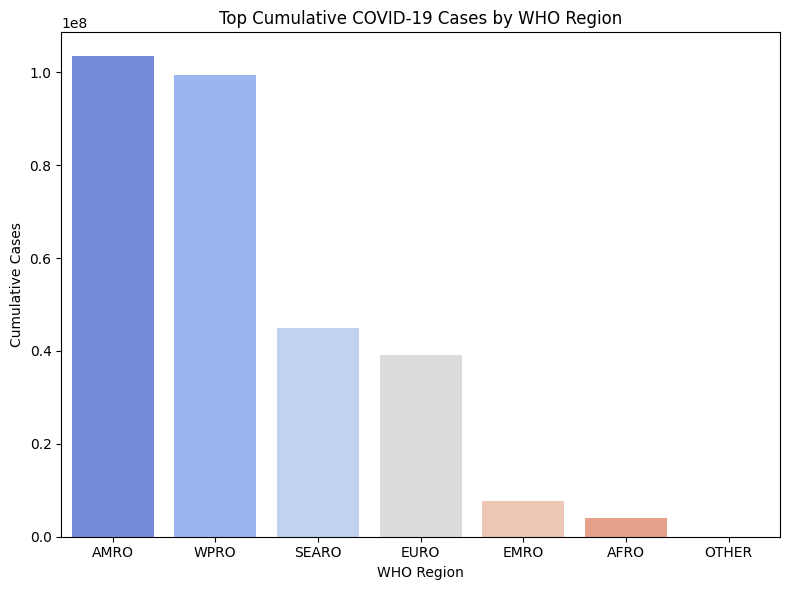

In [44]:
region_cumulative_cases = covid_df.groupby('WHO_region')['Cumulative_cases'].max().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=region_cumulative_cases.index, y=region_cumulative_cases.values, palette='coolwarm')  # Updated palette
plt.title('Top Cumulative COVID-19 Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Cumulative Cases')
plt.tight_layout()
plt.show()

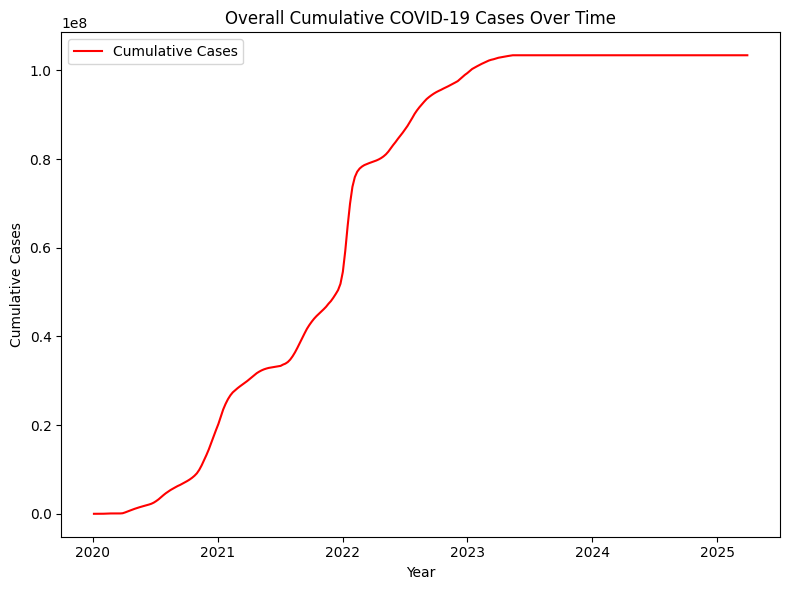

In [34]:
global_cumulative_cases = covid_df.groupby('Date_reported')['Cumulative_cases'].max()
plt.figure(figsize=(8, 6))
plt.plot(global_cumulative_cases.index, global_cumulative_cases.values, color='red', label='Cumulative Cases')
plt.title('Overall Cumulative COVID-19 Cases Over Time')
plt.xlabel('Year')
plt.ylabel('Cumulative Cases')
plt.legend()
plt.tight_layout()
plt.show()

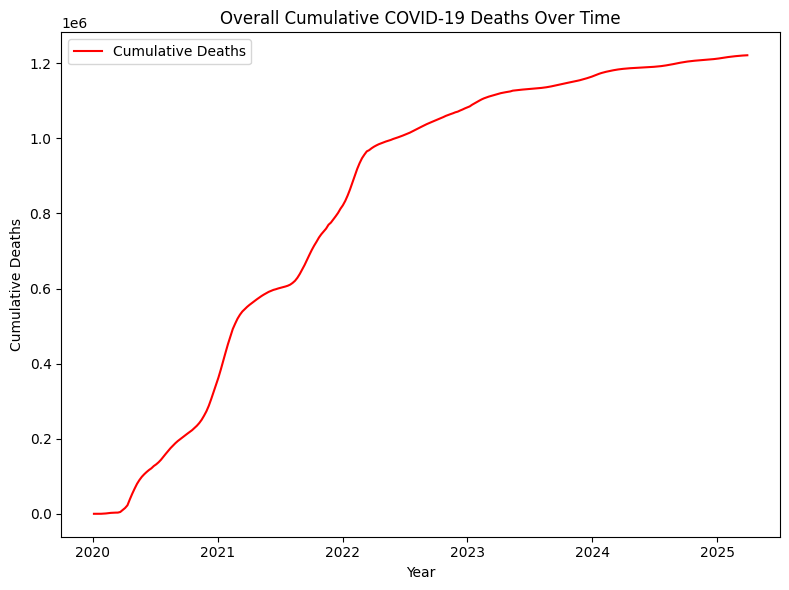

In [39]:
global_cumulative_deaths = covid_df.groupby('Date_reported')['Cumulative_deaths'].max()
plt.figure(figsize=(8, 6))
plt.plot(global_cumulative_deaths.index, global_cumulative_deaths.values, color='red', label='Cumulative Deaths')
plt.title('Overall Cumulative COVID-19 Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Cumulative Deaths')
plt.legend()
plt.tight_layout()
plt.show()

<ipython-input-63-91489f8aae5e>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_countries_deaths.index, y=top_15_countries_deaths.values, palette='magma')


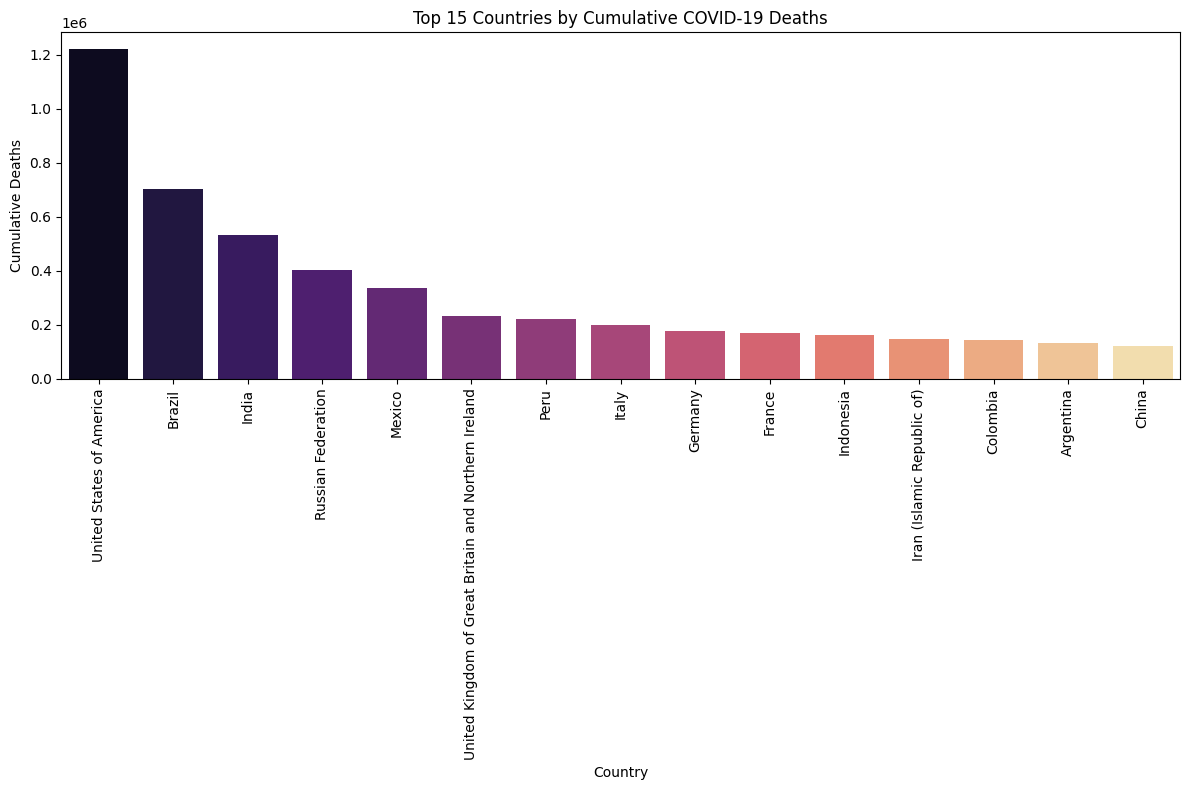

In [63]:
country_cumulative_deaths = covid_df.groupby('Country')['Cumulative_deaths'].max().sort_values(ascending=False)
top_15_countries_deaths = country_cumulative_deaths.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_countries_deaths.index, y=top_15_countries_deaths.values, palette='magma')
plt.title('Top 15 Countries by Cumulative COVID-19 Deaths')
plt.xlabel('Country')
plt.ylabel('Cumulative Deaths')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
